Вариант 3-06
Kernel regression
Этот ноутбук содержит выполнения заданий для лабораторной №3.

_Перед его выполнением, запустите ноутбук с анализом данных `eda3.ipynb`._
# Шаг 0. Импорт библиотек

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

# Task 1

Построить **регрессограммы** для различного числа интервалов группировки:
*     а) 3;
*     б) 10;
*     в) 50.
Построить график зависимости `MSE` непараметрической регрессии на обучающей, валидационной и тестовой выборках от `числа интервалов группировки`.

_Указание: Разбиение на обучающую, валидационную и тестовую выборки – holdout в отношении `60/30/10`._
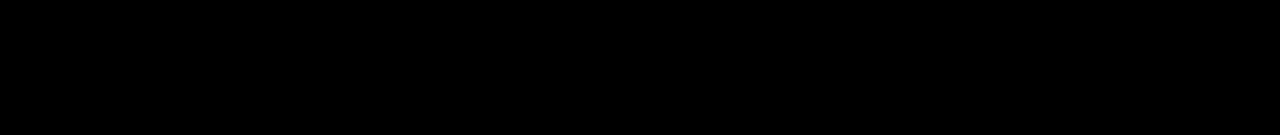
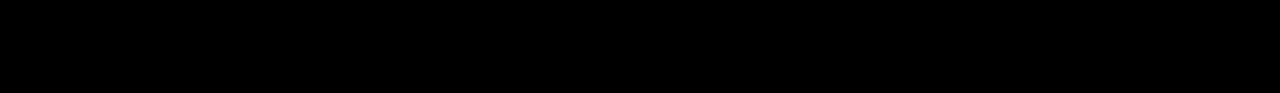

## 1.1 Загрузка и разделение данных

In [70]:
# Загружаем очищенные данные
df = pd.read_csv('../../data/data_ml_v3_cleaned.csv')
df.head()

,x,y
0,-0.60604,-1.179300
1,-0.35888,-2.347900
2,-2.05920,1.811500
3,-1.04380,1.678300
4,-1.11560,-0.018185


In [71]:
# Разбиение на обучающую, валидационную и тестовую выборки (60/30/10)
X = df['x'].values
y = df['y'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.6, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, train_size=0.75, random_state=42
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 180
Размер валидационной выборки: 90
Размер тестовой выборки: 30


## 1.2 Реализация регрессограммы (ядерной регрессии с прямоугольным ядром)

In [72]:
def regressogram(x_train, y_train, x_test, num_bins):
    """
    Регрессограмма - ядерная регрессия с прямоугольным ядром
    """
    # Определяем границы интервалов
    x_min, x_max = x_train.min(), x_train.max()
    bins_edges = np.linspace(x_min, x_max, num_bins + 1)

    y_pred = np.zeros_like(x_test, dtype=float)
    y_pred[0] = np.mean(y_train)

    for i, x in enumerate(x_test):
        # Находим интервал, к которому принадлежит x
        bin_idx = np.digitize(x, bins_edges) - 1
        bin_idx = np.clip(bin_idx, 0, num_bins - 1)

        # Находим точки обучения в этом интервале
        in_bin = (x_train >= bins_edges[bin_idx]) & (x_train <= bins_edges[bin_idx + 1])

        if np.sum(in_bin) > 0:
            # Усредняем значения y в интервале
            y_pred[i] = np.mean(y_train[in_bin.flatten()])
        else:
            # Если интервал пустой, помечаем пердыдущим значением
            y_pred[i] = y_pred[i - 1]

    return y_pred.flatten()


def evaluate_regressogram(X_train, y_train, X_val, y_val, X_test, y_test, num_bins):
    """
    # Функция для вычисления MSE на всех выборках
    """
    # Предсказания на обучающей выборке
    y_train_pred = regressogram(X_train, y_train, X_train, num_bins)
    mse_train = mean_squared_error(y_train, y_train_pred)

    # Предсказания на валидационной выборке
    y_val_pred = regressogram(X_train, y_train, X_val, num_bins)
    mse_val = mean_squared_error(y_val, y_val_pred)

    # Предсказания на тестовой выборке
    y_test_pred = regressogram(X_train, y_train, X_test, num_bins)
    mse_test = mean_squared_error(y_test, y_test_pred)

    return mse_train, mse_val, mse_test

## 1.3 Регрессограммы с `3, 10, 50` интервалами

In [73]:
def paint_regressiogramms(X_train, y_train, num_bins):
    # Визуализация
    plt.figure(figsize=(12, 5))

    # Исходные данные и предсказания
    plt.subplot(1, 2, 1)
    x_plot = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
    y_plot = regressogram(X_train, y_train, x_plot, num_bins)

    plt.scatter(X_train, y_train, alpha=0.3, label='Обучающие данные', s=20)
    plt.scatter(X_val, y_val, alpha=0.3, label='Валидационные данные', s=20, c='green')
    plt.scatter(X_test, y_test, alpha=0.3, label='Тестовые данные', s=20, c='red')
    plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='Регрессограмма')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Регрессограмма с {num_bins} интервалами')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

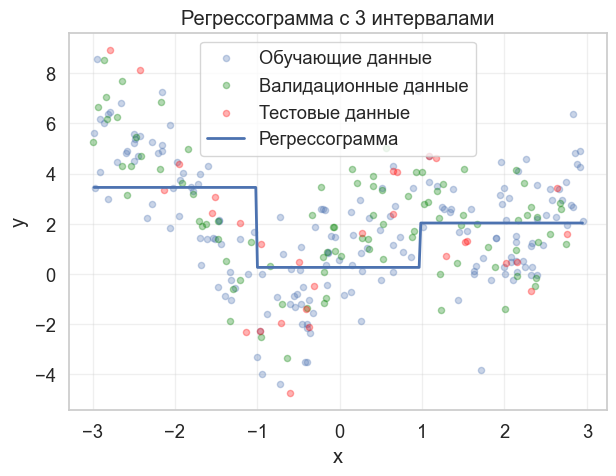

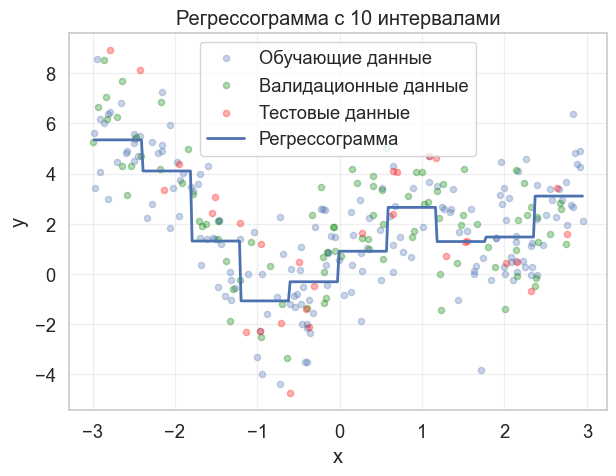

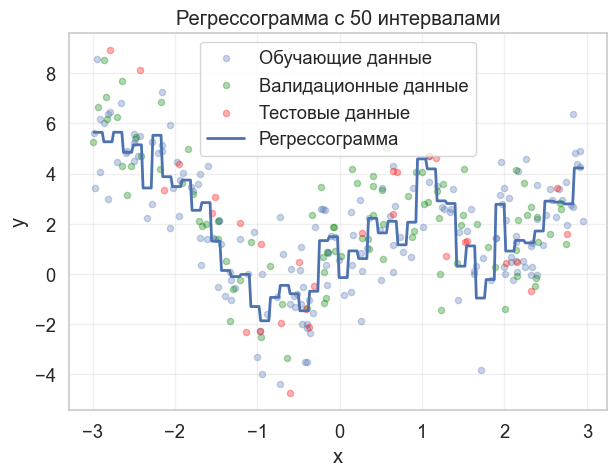

In [74]:
num_bins_a = 3
mse_train_a, mse_val_a, mse_test_a = evaluate_regressogram(
    X_train, y_train, X_val, y_val, X_test, y_test, num_bins_a
)
paint_regressiogramms(X_train, y_train, num_bins_a)

num_bins_b = 10
mse_train_b, mse_val_b, mse_test_b = evaluate_regressogram(
    X_train, y_train, X_val, y_val, X_test, y_test, num_bins_b
)
paint_regressiogramms(X_train, y_train, num_bins_b)

num_bins_c = 50
mse_train_c, mse_val_c, mse_test_c = evaluate_regressogram(
    X_train, y_train, X_val, y_val, X_test, y_test, num_bins_c
)
paint_regressiogramms(X_train, y_train, num_bins_c)

## 1.4 График зависимости MSE от числа интервалов

[4.2674495002497865, 2.6101998459249787, 1.65930838377731]
[4.837305076203294, 2.996714828847028, 2.7101015487179203]
[6.733820671272272, 2.964706902067699, 3.191146483682767]


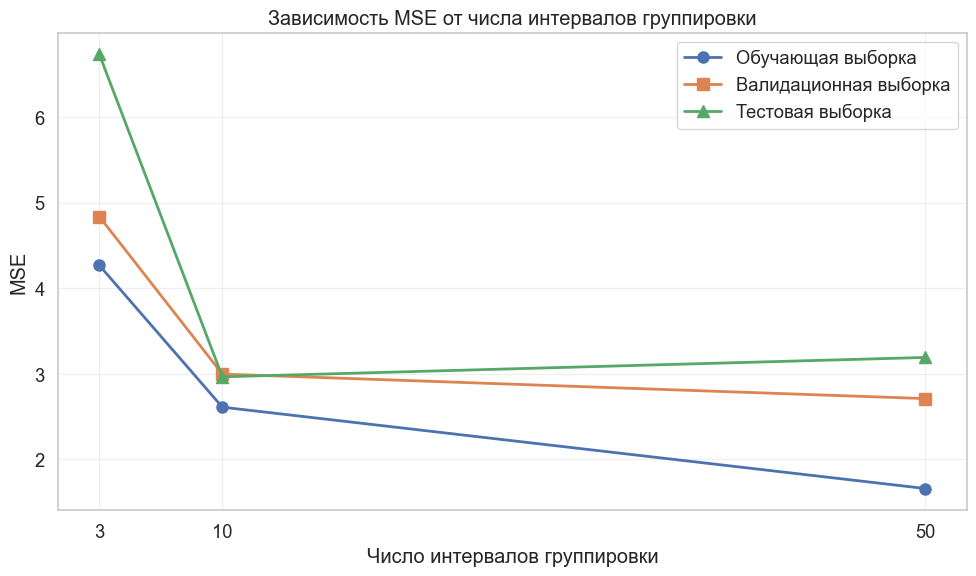

In [75]:
# Данные для графика
bin_numbers = [3, 10, 50]
mse_train = [mse_train_a, mse_train_b, mse_train_c]
mse_val = [mse_val_a, mse_val_b, mse_val_c]
mse_test = [mse_test_a, mse_test_b, mse_test_c]
print(mse_train)
print(mse_val)
print(mse_test)

# Построение графика
plt.figure(figsize=(10, 6))

plt.plot(bin_numbers, mse_train, 'o-', label='Обучающая выборка', linewidth=2, markersize=8)
plt.plot(bin_numbers, mse_val, 's-', label='Валидационная выборка', linewidth=2, markersize=8)
plt.plot(bin_numbers, mse_test, '^-', label='Тестовая выборка', linewidth=2, markersize=8)

plt.xlabel('Число интервалов группировки')
plt.ylabel('MSE')
plt.title('Зависимость MSE от числа интервалов группировки')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(bin_numbers)

plt.tight_layout()
plt.show()

# Task 2

Построить графики зависимости `MSE` ядерной регрессии на обучающей, валидационной и тестовой выборках от `ширины окна` для:
*     а) прямоугольного окна;
*     б) гауссова окна;
*     в) окна Епанечникова;
*     г) треугольного окна.
Определить оптимальную ширину каждого окна.
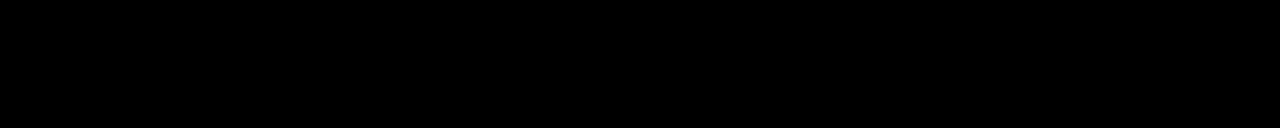

## 2.1 Подготовка

In [76]:
def kernel_regression(X_train, y_train, X_test, h, kernel_type='gaussian'):
    """
    Ядерная регрессия Надарая-Ватсона
    """
    n_train = len(X_train)
    n_test = len(X_test)
    y_pred = np.zeros(n_test)

    for i, x in enumerate(X_test):
        # Вычисляем веса для всех обучающих точек
        weights = np.zeros(n_train)

        for j, x_train in enumerate(X_train):
            u = (x - x_train) / h

            if kernel_type == 'rectangular':
                # Прямоугольное ядро
                weights[j] = 0.5 if abs(u) <= 1 else 0

            elif kernel_type == 'gaussian':
                # Гауссово ядро
                weights[j] = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * u**2)

            elif kernel_type == 'epanechnikov':
                # Ядро Епанечникова
                if abs(u) <= 1:
                    weights[j] = 0.75 * (1 - u**2)
                else:
                    weights[j] = 0

            elif kernel_type == 'triangular':
                # Треугольное ядро
                if abs(u) <= 1:
                    weights[j] = 1 - abs(u)
                else:
                    weights[j] = 0

        # Нормируем веса и делаем предсказание
        if np.sum(weights) > 0:
            weights = weights / np.sum(weights)
            y_pred[i] = np.sum(weights * y_train.flatten())
        else:
            y_pred[i] = np.mean(y_train)

    return y_pred


def evaluate_kernel(X_train, y_train, X_val, y_val, X_test, y_test, h_values, kernel_type):
    """
    Функция для вычисления MSE при разных h
    """
    mse_train = []
    mse_val = []
    mse_test = []

    for h in h_values:
        # Предсказания на обучающей выборке
        y_train_pred = kernel_regression(X_train, y_train, X_train, h, kernel_type)
        mse_train.append(mean_squared_error(y_train, y_train_pred))

        # Предсказания на валидационной выборке
        y_val_pred = kernel_regression(X_train, y_train, X_val, h, kernel_type)
        mse_val.append(mean_squared_error(y_val, y_val_pred))

        # Предсказания на тестовой выборке
        y_test_pred = kernel_regression(X_train, y_train, X_test, h, kernel_type)
        mse_test.append(mean_squared_error(y_test, y_test_pred))

    return mse_train, mse_val, mse_test

## 2.2 Оптимальное значение MSE для различных ядер

In [77]:
def paint_mse_vs_window(h_values, optimal_h, mse_train, mse_val, mse_test, name="Прямоугольное ядро"):
    """
    Функция для построение графика
    """
    plt.figure(figsize=(10, 6))
    plt.plot(h_values, mse_train, 'b-', label='Обучающая выборка', linewidth=2)
    plt.plot(h_values, mse_val, 'g-', label='Валидационная выборка', linewidth=2)
    plt.plot(h_values, mse_test, 'r-', label='Тестовая выборка', linewidth=2)
    plt.axvline(x=optimal_h, color='k', linestyle='--', alpha=0.5, label=f'Оптимум h={optimal_h:.2f}')
    plt.xlabel('Ширина окна (h)')
    plt.ylabel('MSE')
    plt.title(f'Зависимость MSE от ширины окна ({name})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

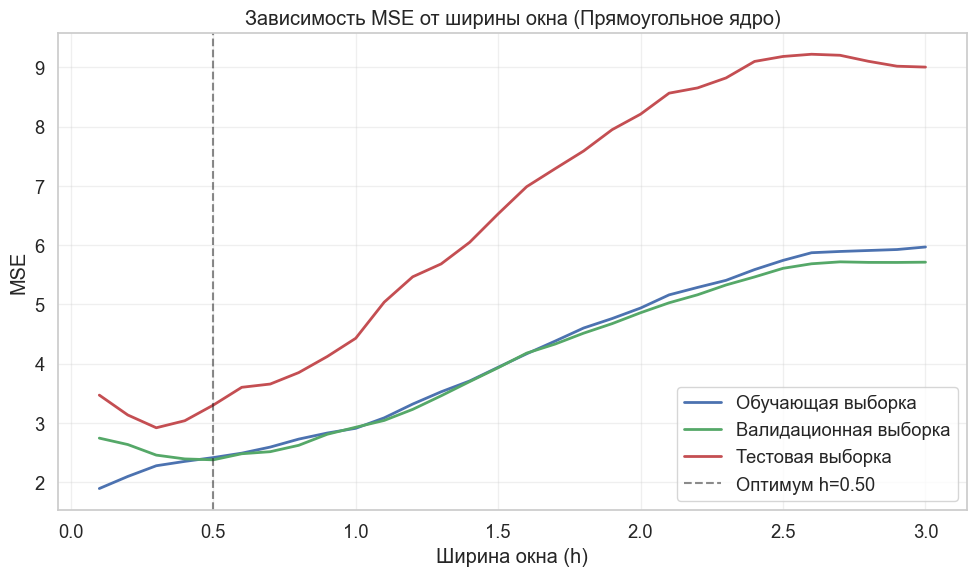

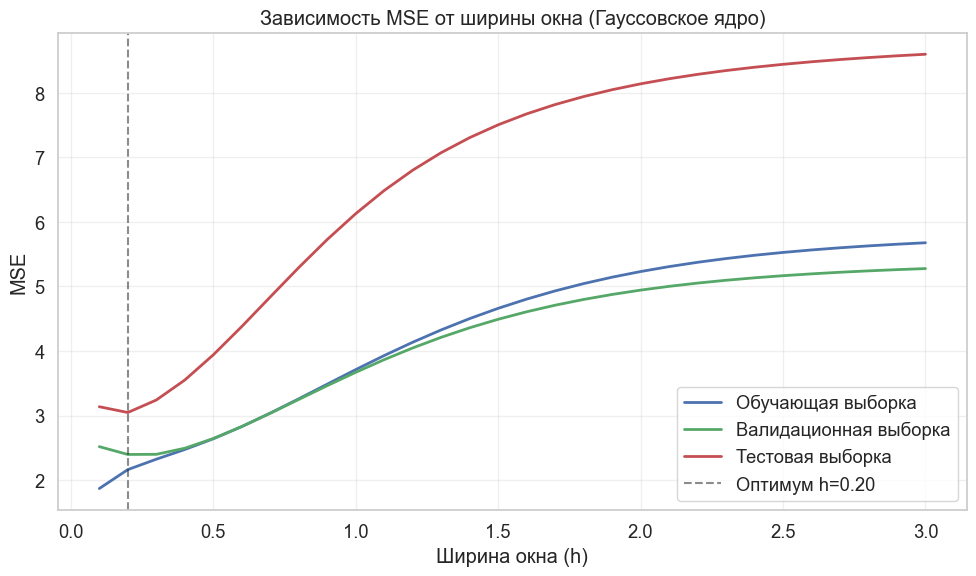

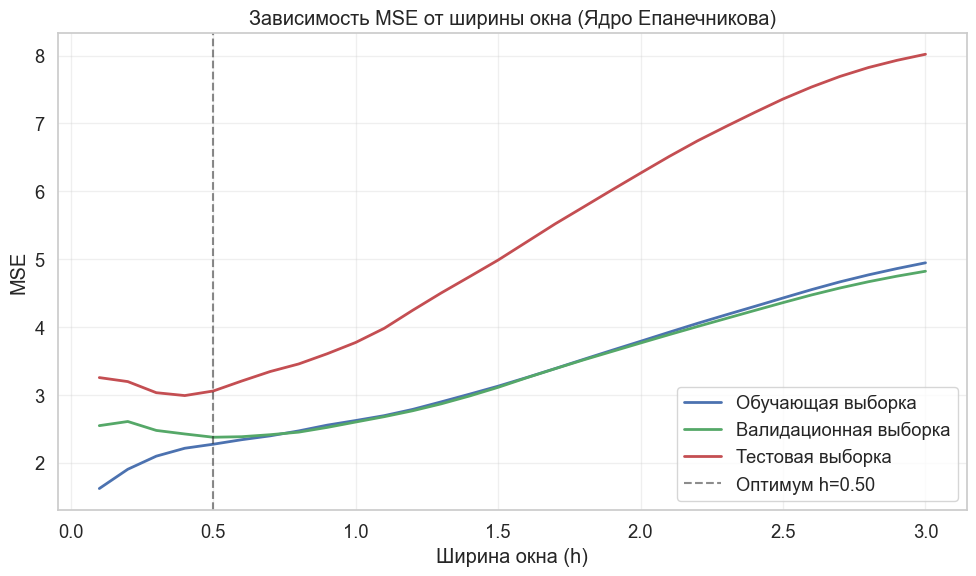

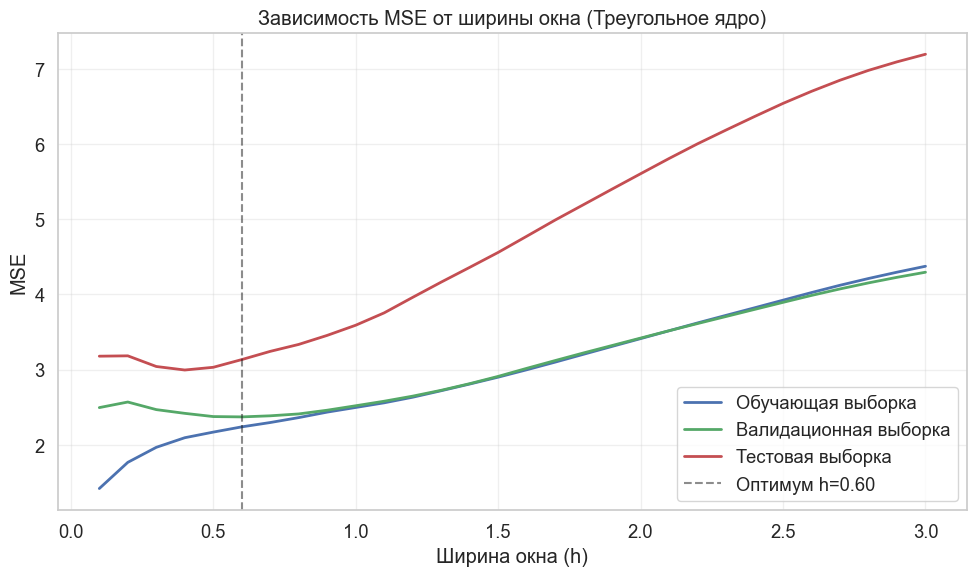

In [89]:
# Диапазон значений ширины окна
h_values = np.linspace(0.1, 3.0, 30)

# Прямоугольное окно
# Вычисляем MSE для прямоугольного ядра
mse_train_rect, mse_val_rect, mse_test_rect = evaluate_kernel(
    X_train, y_train, X_val, y_val, X_test, y_test, h_values, 'rectangular'
)

# Находим оптимальную ширину окна по валидационной выборке
optimal_h_rect = h_values[np.argmin(mse_val_rect)]
optimal_mse_rect = min(mse_val_rect)

# Визуализация
paint_mse_vs_window(h_values, optimal_h_rect, mse_train_rect, mse_val_rect, mse_test_rect, name="Прямоугольное ядро")

# Гауссово окно
# Вычисляем MSE для гауссова ядра
mse_train_gauss, mse_val_gauss, mse_test_gauss = evaluate_kernel(
    X_train, y_train, X_val, y_val, X_test, y_test, h_values, 'gaussian'
)

# Находим оптимальную ширину окна по валидационной выборке
optimal_h_gauss = h_values[np.argmin(mse_val_gauss)]
optimal_mse_gauss = min(mse_val_gauss)

# Визуализация
paint_mse_vs_window(h_values, optimal_h_gauss, mse_train_gauss, mse_val_gauss, mse_test_gauss, name="Гауссовское ядро")

# Окно Епанечникова
# Вычисляем MSE для ядра Епанечникова
mse_train_epan, mse_val_epan, mse_test_epan = evaluate_kernel(
    X_train, y_train, X_val, y_val, X_test, y_test, h_values, 'epanechnikov'
)

# Находим оптимальную ширину окна по валидационной выборке
optimal_h_epan = h_values[np.argmin(mse_val_epan)]
optimal_mse_epan = min(mse_val_epan)

# Визуализация
paint_mse_vs_window(h_values, optimal_h_epan, mse_train_epan, mse_val_epan, mse_test_epan, name="Ядро Епанечникова")

# Треугольное окно
# Вычисляем MSE для треугольного ядра
mse_train_tri, mse_val_tri, mse_test_tri = evaluate_kernel(
    X_train, y_train, X_val, y_val, X_test, y_test, h_values, 'triangular'
)

# Находим оптимальную ширину окна по валидационной выборке
optimal_h_tri = h_values[np.argmin(mse_val_tri)]
optimal_mse_tri = min(mse_val_tri)

# Визуализация
paint_mse_vs_window(h_values, optimal_h_tri, mse_train_tri, mse_val_tri, mse_test_tri, name="Треугольное ядро")

# Task 3

Визуализировать графики ядерной функции регрессии, полученной с использованием:
* а) прямоугольного окна;
* б) гауссова окна;
* в) окна Епанечникова;
* г) треугольного окна.

Ширину окна задать:
* i) равной соответствующему оптимальному значению, полученному в п.2;
* ii) значению, меньшему оптимального;
* iii) значению, большему оптимального.
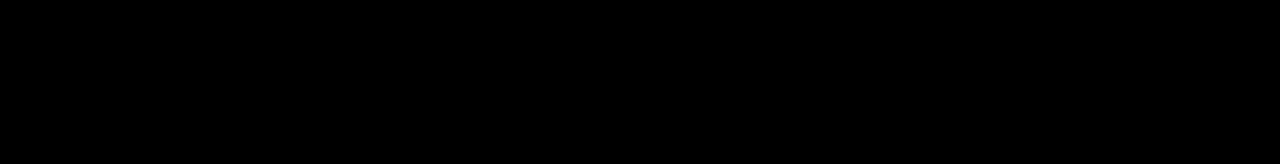

## 3.1 Подготовка

In [79]:
def plot_kernel_regression(X_train, y_train, X_test, h, kernel_type, title, ax):
    """
    Функция для визуализации ядерной регрессии
    """
    # Получаем предсказания
    y_pred = kernel_regression(X_train, y_train, X_test, h, kernel_type)

    # Сортируем точки для гладкой линии
    sort_idx = np.argsort(X_test.flatten())
    X_sorted = X_test[sort_idx]
    y_sorted = y_pred[sort_idx]

    # Рисуем
    ax.scatter(X_train, y_train, alpha=0.3, s=10, label='Обучающие данные')
    ax.plot(X_sorted, y_sorted, 'r-', linewidth=2, label='Ядерная регрессия')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

In [80]:
# Создаем тестовые точки для визуализации
X_plot = np.linspace(X_train.min(), X_train.max(), 500).reshape(-1, 1)

# Определяем значения ширины окна для каждого типа ядра
# Оптимальные значения из предыдущего задания
h_opt_rect = optimal_h_rect
h_opt_gauss = optimal_h_gauss
h_opt_epan = optimal_h_epan
h_opt_tri = optimal_h_tri

# Меньше оптимального (примерно в 2 раза меньше)
h_small_rect = h_opt_rect / 2
h_small_gauss = h_opt_gauss / 2
h_small_epan = h_opt_epan / 2
h_small_tri = h_opt_tri / 2

# Больше оптимального (примерно в 2 раза больше)
h_large_rect = h_opt_rect * 2
h_large_gauss = h_opt_gauss * 2
h_large_epan = h_opt_epan * 2
h_large_tri = h_opt_tri * 2

## 3.2 Построения ядерной оцеки для разных видов ядер

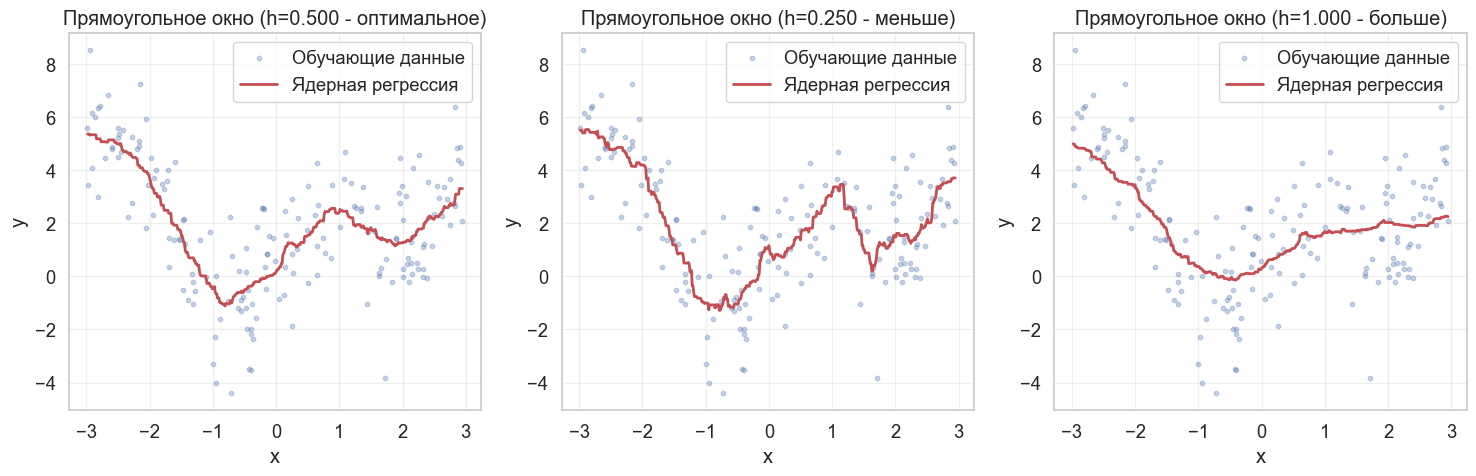

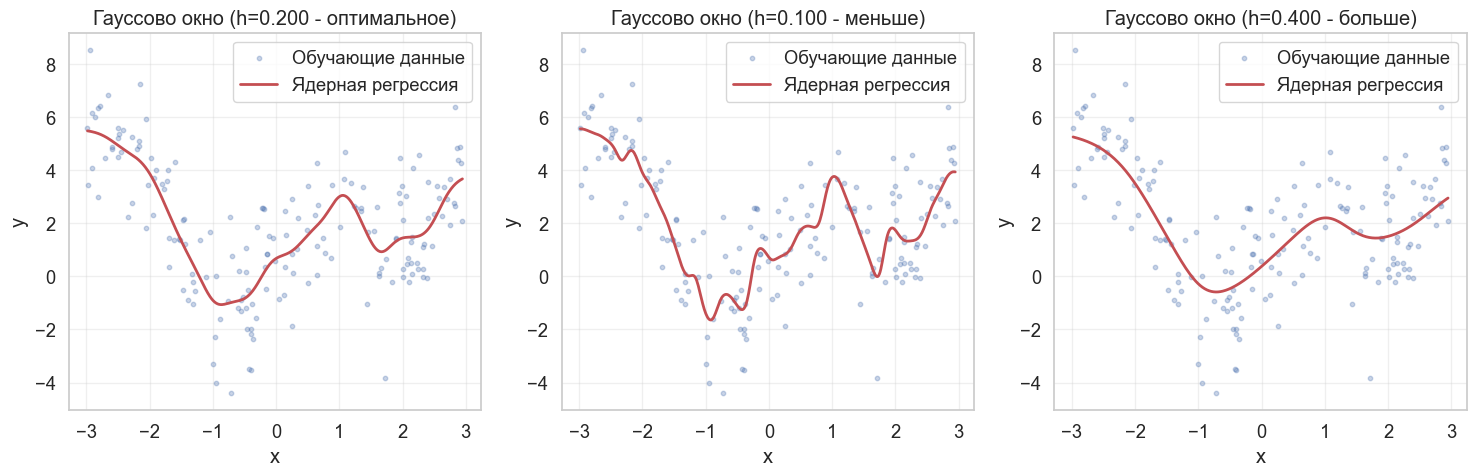

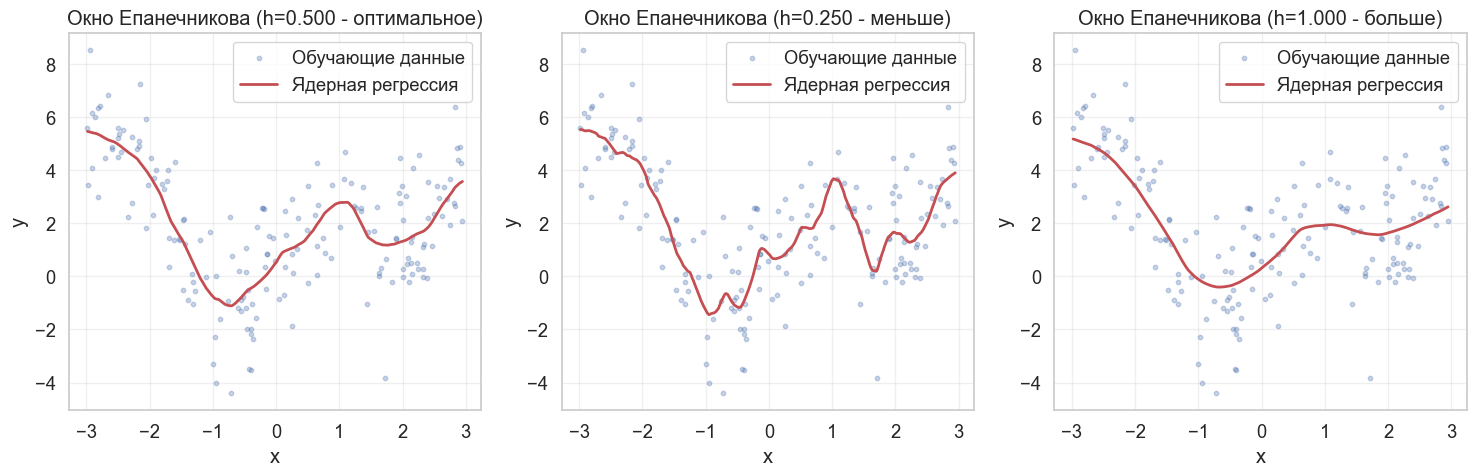

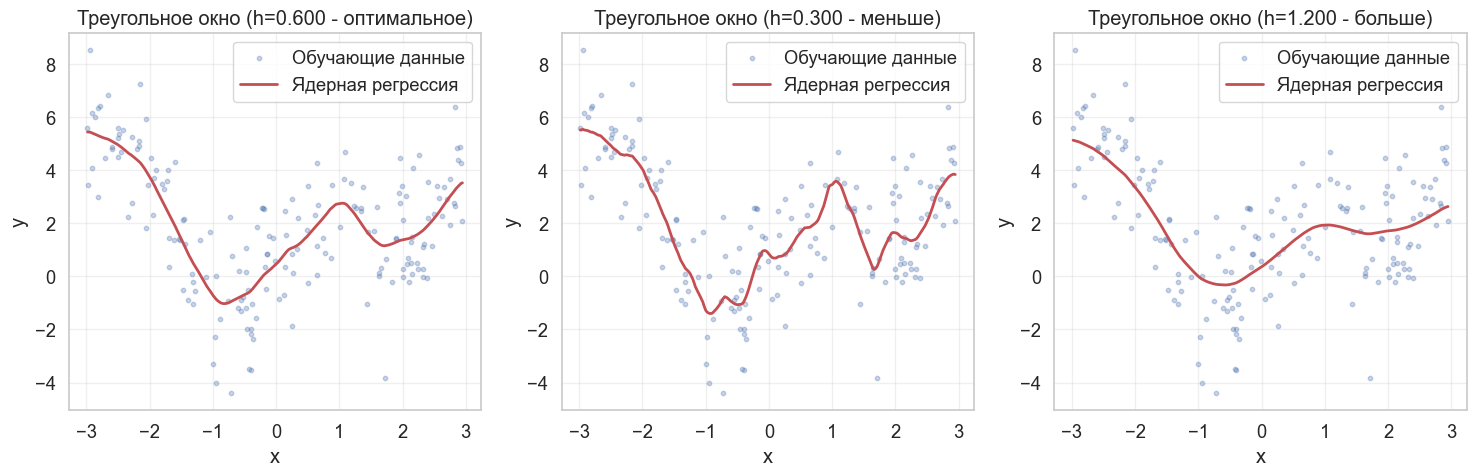

In [81]:
# Прямоугольное окно
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# i) Оптимальная ширина
plot_kernel_regression(X_train, y_train, X_plot, h_opt_rect, 'rectangular',
                        f'Прямоугольное окно (h={h_opt_rect:.3f} - оптимальное)', axes[0])

# ii) Меньше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_small_rect, 'rectangular',
                        f'Прямоугольное окно (h={h_small_rect:.3f} - меньше)', axes[1])

# iii) Больше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_large_rect, 'rectangular',
                        f'Прямоугольное окно (h={h_large_rect:.3f} - больше)', axes[2])

plt.tight_layout()
plt.show()

# Гауссово окно
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# i) Оптимальная ширина
plot_kernel_regression(X_train, y_train, X_plot, h_opt_gauss, 'gaussian',
                        f'Гауссово окно (h={h_opt_gauss:.3f} - оптимальное)', axes[0])

# ii) Меньше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_small_gauss, 'gaussian',
                        f'Гауссово окно (h={h_small_gauss:.3f} - меньше)', axes[1])

# iii) Больше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_large_gauss, 'gaussian',
                        f'Гауссово окно (h={h_large_gauss:.3f} - больше)', axes[2])

plt.tight_layout()
plt.show()

# Окно Епанечникова
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# i) Оптимальная ширина
plot_kernel_regression(X_train, y_train, X_plot, h_opt_epan, 'epanechnikov',
                        f'Окно Епанечникова (h={h_opt_epan:.3f} - оптимальное)', axes[0])

# ii) Меньше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_small_epan, 'epanechnikov',
                        f'Окно Епанечникова (h={h_small_epan:.3f} - меньше)', axes[1])

# iii) Больше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_large_epan, 'epanechnikov',
                        f'Окно Епанечникова (h={h_large_epan:.3f} - больше)', axes[2])

plt.tight_layout()
plt.show()

# Треугольное окно
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# i) Оптимальная ширина
plot_kernel_regression(X_train, y_train, X_plot, h_opt_tri, 'triangular',
                        f'Треугольное окно (h={h_opt_tri:.3f} - оптимальное)', axes[0])

# ii) Меньше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_small_tri, 'triangular',
                        f'Треугольное окно (h={h_small_tri:.3f} - меньше)', axes[1])

# iii) Больше оптимального
plot_kernel_regression(X_train, y_train, X_plot, h_large_tri, 'triangular',
                        f'Треугольное окно (h={h_large_tri:.3f} - больше)', axes[2])

plt.tight_layout()
plt.show()

# Task 4

Построить графики зависимости `дисперсии` и `смещения регрессионной модели` для нескольких фиксированных значений `x` от `ширины окна` для:
* а) прямоугольного окна;
* б) гауссова окна;
* в) окна Епанечникова;
* г) треугольного окна.
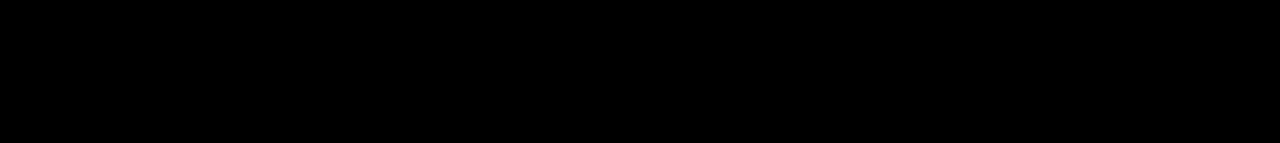
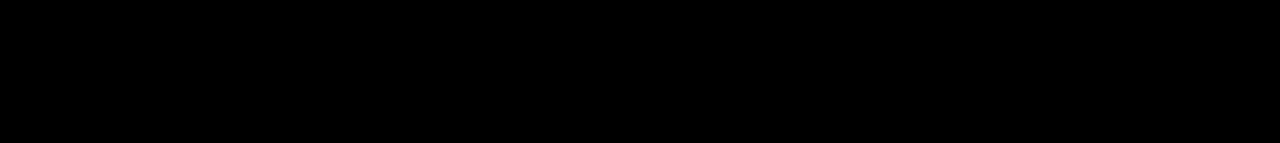

## 4.1 Подготовка

In [82]:
def estimate_bias_variance_bootstrap(X_train, y_train, X_fixed_points, h_values, kernel_type, n_bootstrap=100):
    """
    Оценка смещения и дисперсии методом бутстрепа
    """
    n_points = len(X_fixed_points)
    n_h = len(h_values)

    # Массивы для результатов
    bias_squared = np.zeros((n_h, n_points))
    variance = np.zeros((n_h, n_points))

    for i, h in enumerate(h_values):
        # Массив для предсказаний на бутстреп-выборках
        bootstrap_preds = np.zeros((n_bootstrap, n_points))

        for b in range(n_bootstrap):
            # Генерируем бутстреп-выборку
            X_boot, y_boot = resample(X_train, y_train, random_state=b)

            # Получаем предсказания для фиксированных точек
            y_pred = kernel_regression(X_boot, y_boot, X_fixed_points, h, kernel_type)
            bootstrap_preds[b, :] = y_pred.flatten()

        # Среднее предсказание по бутстреп-выборкам
        mean_pred = np.mean(bootstrap_preds, axis=0)

        # Предсказание на исходных данных (как приближение истинной функции)
        y_pred_original = kernel_regression(X_train, y_train, X_fixed_points, h, kernel_type)

        # Смещение^2 = (среднее предсказание - предсказание на исходных)^2
        bias_squared[i, :] = (mean_pred - y_pred_original.flatten())**2

        # Дисперсия = средний квадрат отклонений от среднего предсказания
        variance[i, :] = np.var(bootstrap_preds, axis=0, ddof=1)

    return bias_squared, variance

# Выбираем несколько фиксированных точек x для анализа
x_fixed = np.array([-2, -1, 0, 1, 2]).reshape(-1, 1)
x_fixed_labels = ['x = -2', 'x = -1', 'x = 0', 'x = 1', 'x = 2']

# Диапазон значений ширины окна для анализа
h_values_analysis = np.linspace(0.2, 3.0, 20)

In [83]:
def paint_dispers_and_bias(bias_sq, var):
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # График смещения^2
    for i, label in enumerate(x_fixed_labels):
        axes[0].plot(h_values_analysis, bias_sq[:, i], 'o-', label=label, linewidth=2)
    axes[0].set_xlabel('Ширина окна (h)')
    axes[0].set_ylabel('Смещение²')
    axes[0].set_title('Зависимость смещения² от ширины окна (Прямоугольное окно)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График дисперсии
    for i, label in enumerate(x_fixed_labels):
        axes[1].plot(h_values_analysis, var[:, i], 'o-', label=label, linewidth=2)
    axes[1].set_xlabel('Ширина окна (h)')
    axes[1].set_ylabel('Дисперсия')
    axes[1].set_title('Зависимость дисперсии от ширины окна (Прямоугольное окно)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4.2 Графики зависимости `дисперсии` и `смещения регрессионной модели` от `ширины окна`

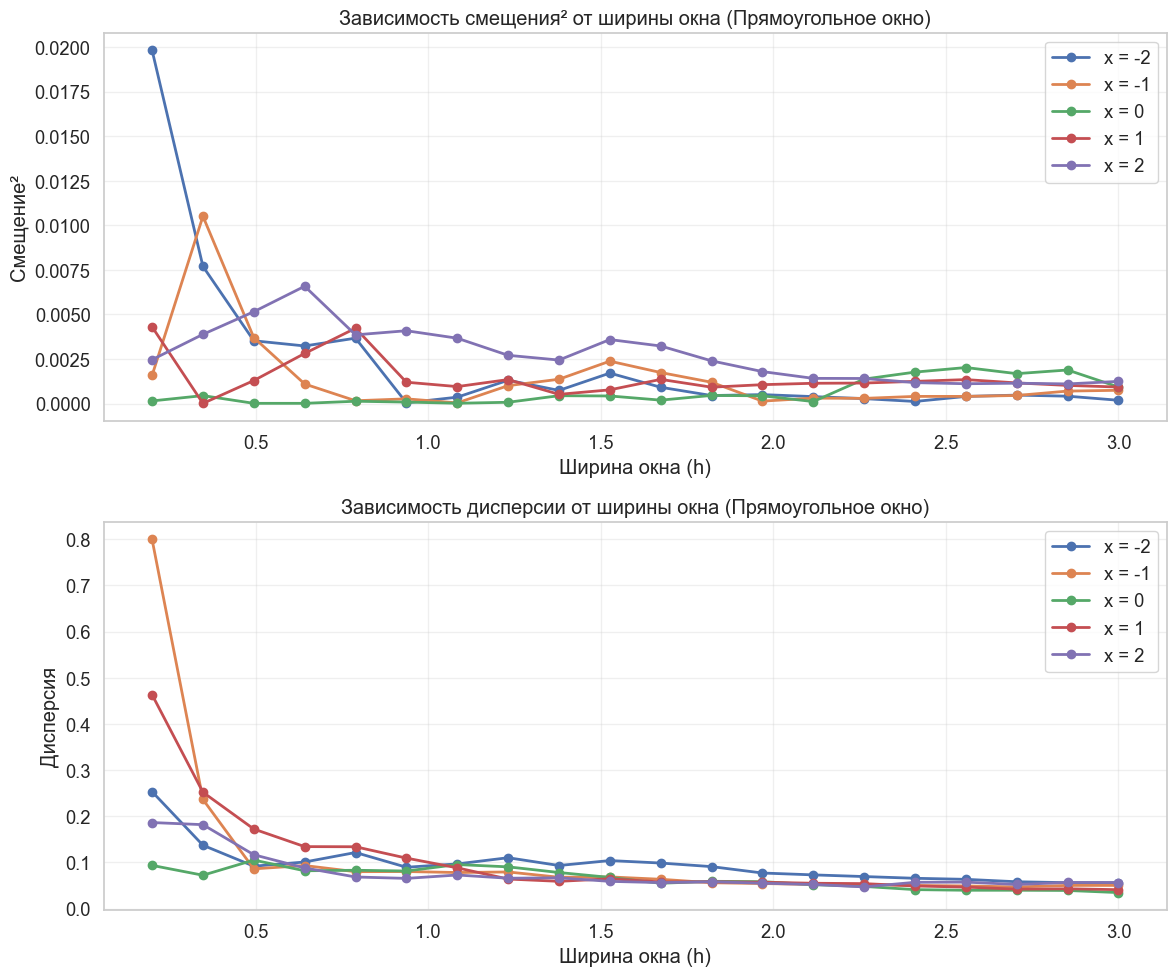

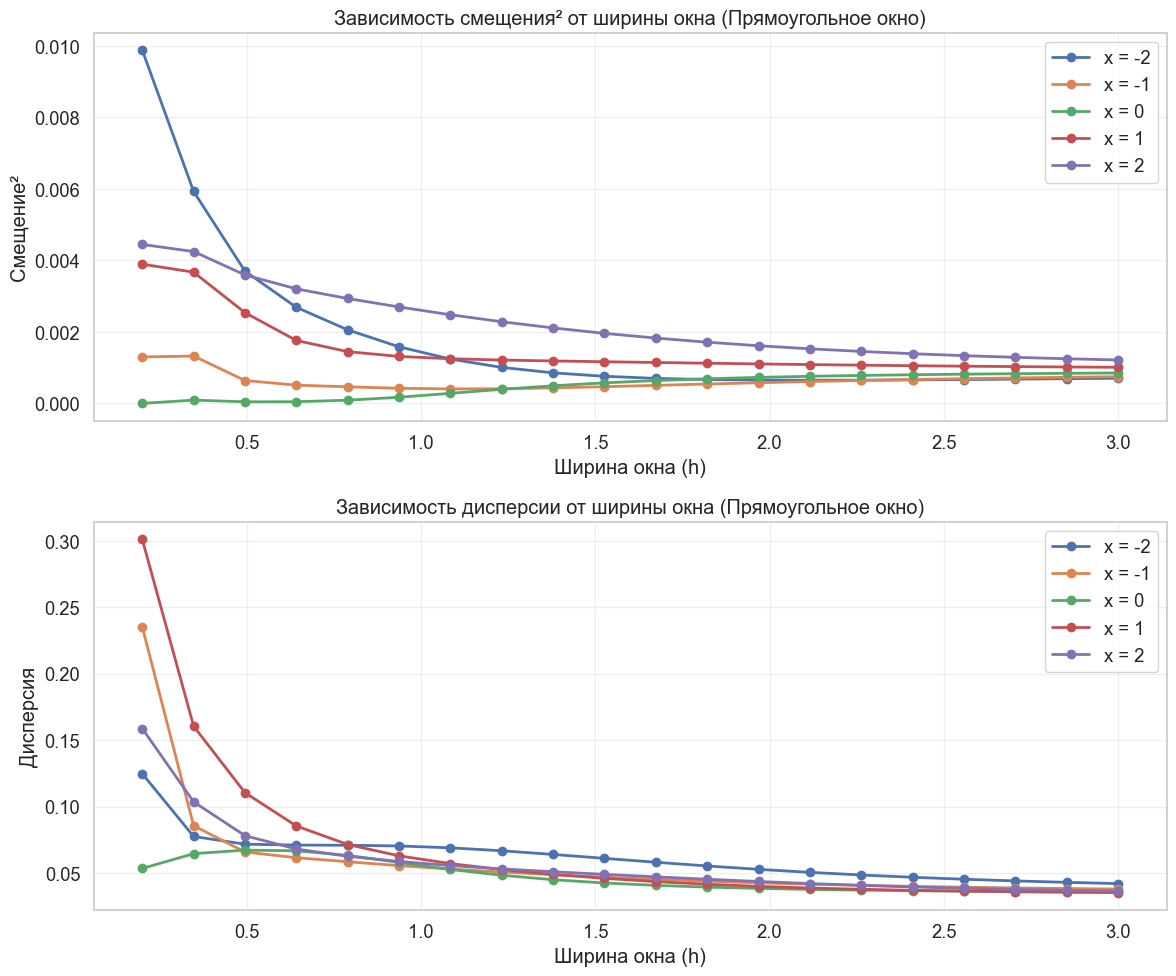

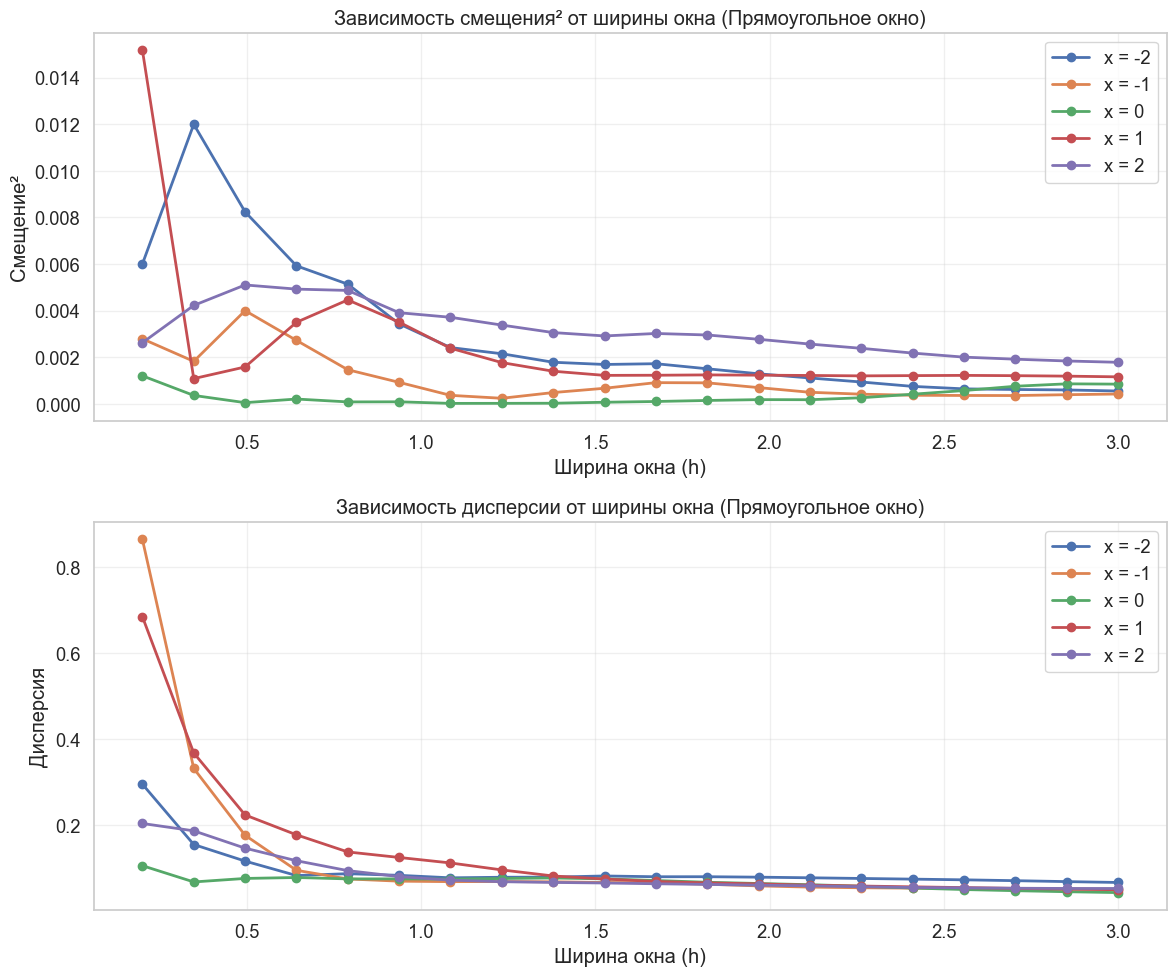

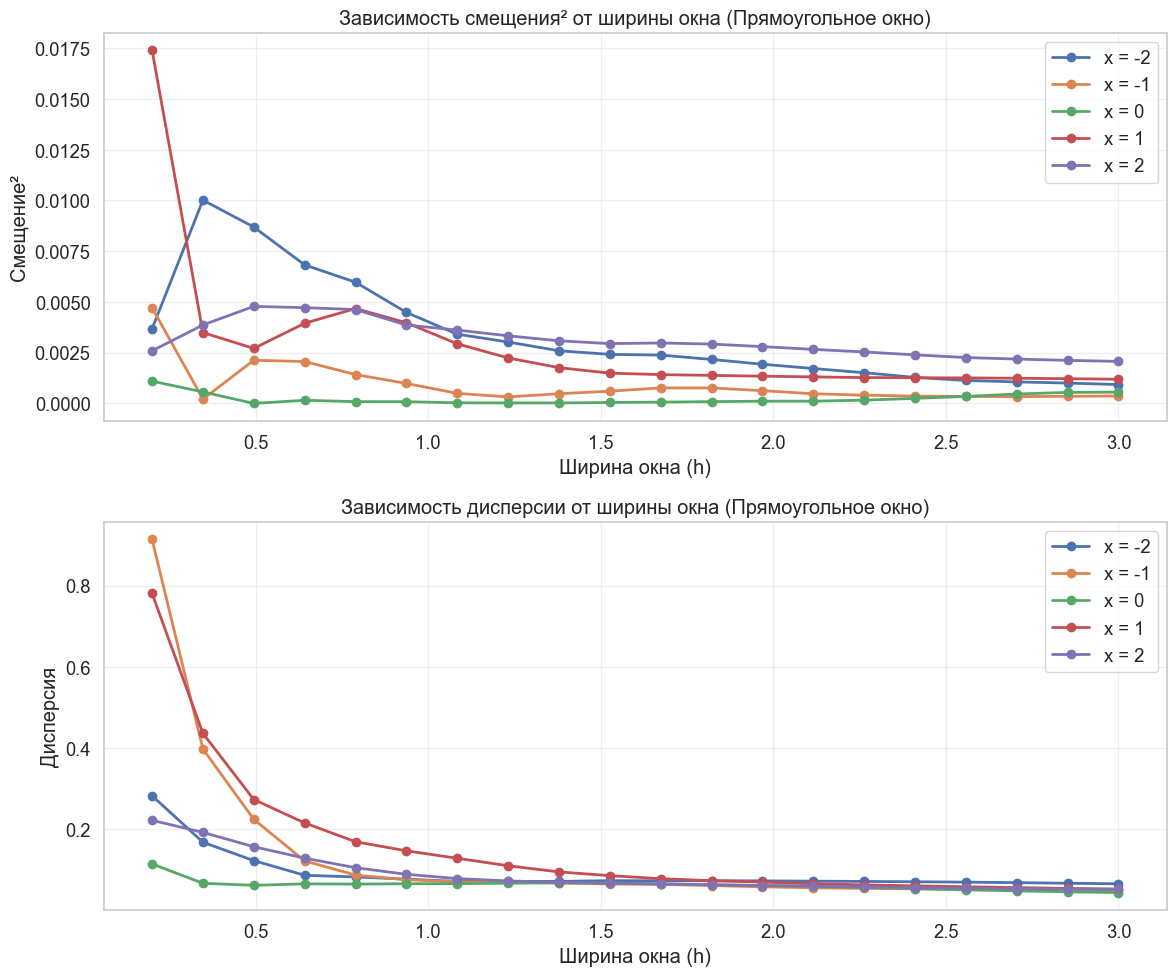

In [84]:
# Прямоугольное окно
bias_sq_rect, var_rect = estimate_bias_variance_bootstrap(
    X_train, y_train, x_fixed, h_values_analysis, 'rectangular', n_bootstrap=50
)
paint_dispers_and_bias(bias_sq_rect, var_rect)

# Гауссово окно
bias_sq_gauss, var_gauss = estimate_bias_variance_bootstrap(
    X_train, y_train, x_fixed, h_values_analysis, 'gaussian', n_bootstrap=50
)
paint_dispers_and_bias(bias_sq_gauss, var_gauss)

# Окно Епанечникова
bias_sq_epan, var_epan = estimate_bias_variance_bootstrap(
    X_train, y_train, x_fixed, h_values_analysis, 'epanechnikov', n_bootstrap=50
)
paint_dispers_and_bias(bias_sq_epan, var_epan)

# Треугольное окно
bias_sq_tri, var_tri = estimate_bias_variance_bootstrap(
    X_train, y_train, x_fixed, h_values_analysis, 'triangular', n_bootstrap=50
)
paint_dispers_and_bias(bias_sq_tri, var_tri)

# Task 5

1. Построить график зависимости MSE KNN-регрессии от числа ближайших соседей K на обучающей и тестовой выборках.
2. Определить оптимальное число ближайших соседей и визуализировать графики KNN-регрессии для различных значений K:
    * а) равному оптимальному;
    * б) меньшего оптимального;
    * в) большего оптимального.
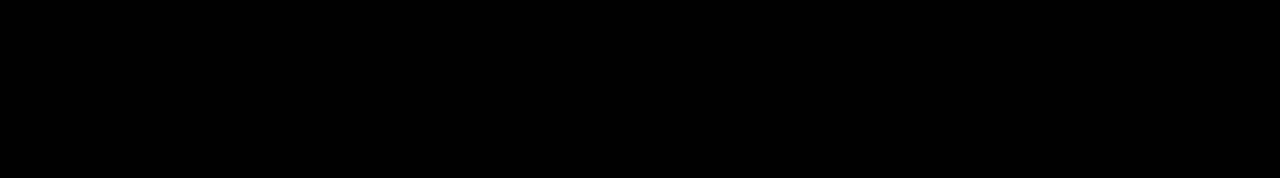

## 5.1: Зависимость MSE от числа соседей K

In [85]:
# Проверим и приведем данные к правильной форме
print(f"Форма X_train до преобразования: {X_train.shape}")
print(f"Форма y_train до преобразования: {y_train.shape}")

# Убедимся, что X имеет форму (n_samples, n_features)
if len(X_train.shape) == 1:
    X_train = X_train.reshape(-1, 1)
if len(X_test.shape) == 1:
    X_test = X_test.reshape(-1, 1)
if len(y_train.shape) > 1 and y_train.shape[1] == 1:
    y_train = y_train.ravel()
if len(y_test.shape) > 1 and y_test.shape[1] == 1:
    y_test = y_test.ravel()

print(f"\nФорма X_train после преобразования: {X_train.shape}")
print(f"Форма y_train после преобразования: {y_train.shape}")

Форма X_train до преобразования: (180,)
Форма y_train до преобразования: (180,)

Форма X_train после преобразования: (180, 1)
Форма y_train после преобразования: (180,)


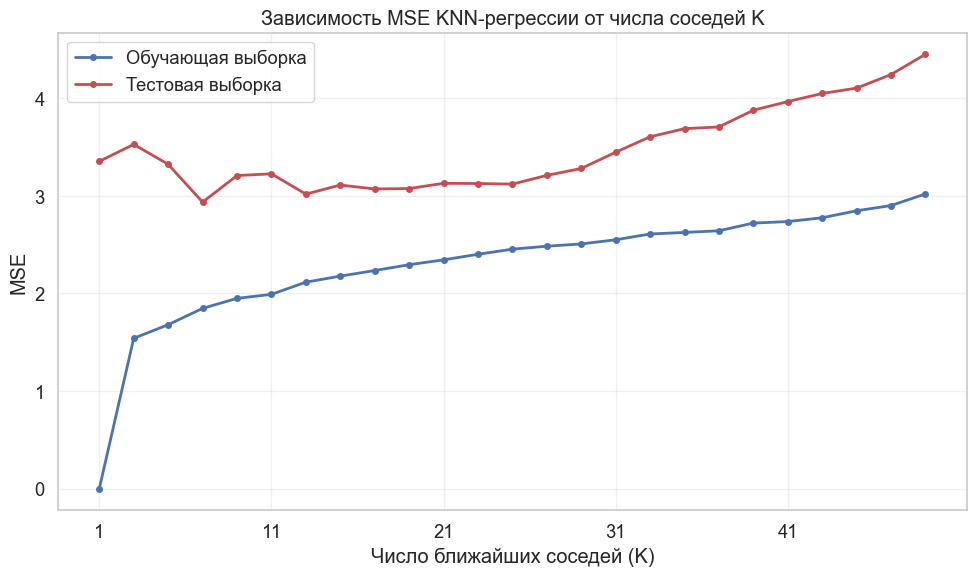

Оптимальное число соседей K: 7
MSE при оптимальном K на тестовой выборке: 2.936777


In [86]:
# Диапазон значений K для исследования
k_values = range(1, 51, 2)  # нечетные значения от 1 до 50
mse_train_knn = []
mse_test_knn = []

for k in k_values:
    # Создаем и обучаем KNN-регрессор
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Предсказания на обучающей выборке
    y_train_pred = knn.predict(X_train)
    mse_train_knn.append(mean_squared_error(y_train, y_train_pred))

    # Предсказания на тестовой выборке
    y_test_pred = knn.predict(X_test)
    mse_test_knn.append(mean_squared_error(y_test, y_test_pred))

# Построение графика зависимости MSE от K
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_train_knn, 'b-o', label='Обучающая выборка', linewidth=2, markersize=4)
plt.plot(k_values, mse_test_knn, 'r-o', label='Тестовая выборка', linewidth=2, markersize=4)
plt.xlabel('Число ближайших соседей (K)')
plt.ylabel('MSE')
plt.title('Зависимость MSE KNN-регрессии от числа соседей K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values[::5])  # Отмечаем каждый 5-й K
plt.tight_layout()
plt.show()

# Находим оптимальное K по тестовой ошибке
optimal_k = k_values[np.argmin(mse_test_knn)]
optimal_mse = min(mse_test_knn)

print(f"Оптимальное число соседей K: {optimal_k}")
print(f"MSE при оптимальном K на тестовой выборке: {optimal_mse:.6f}")

## 5.2: KNN-регрессия с оптимальным K

In [87]:
def paint_knn_regression(X_train, y_train, X_test, y_test, X_plot, y_plot, k):
    """
    Функция для визуализации
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, y_train, alpha=0.3, s=20, label='Обучающие данные')
    plt.scatter(X_test, y_test, alpha=0.3, s=20, c='red', label='Тестовые данные')
    plt.plot(X_plot, y_plot, 'g-', linewidth=2, label=f'KNN регрессия (K={k} - оптимальное)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'KNN-регрессия с оптимальным числом соседей K={k}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

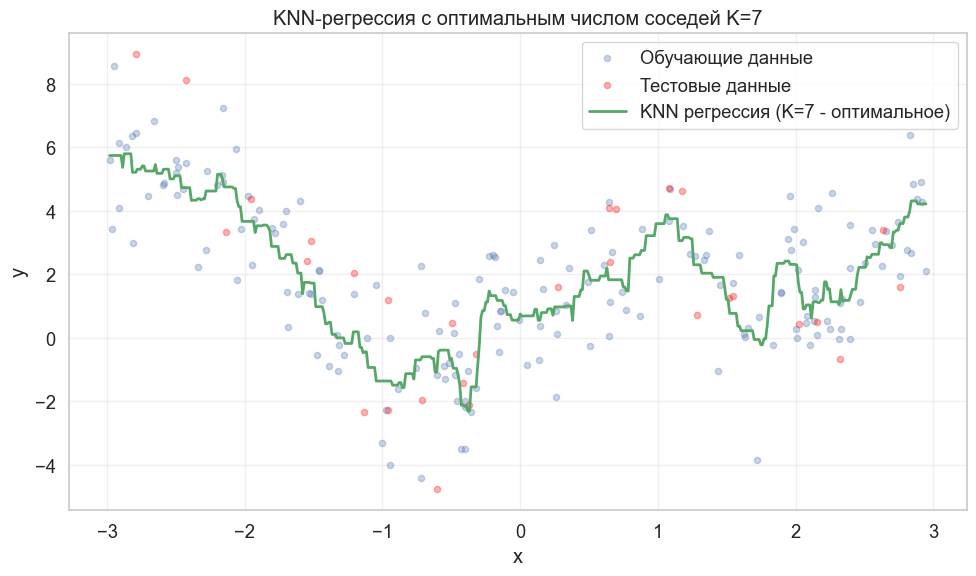

MSE на тестовой выборке при K=7: 2.936777


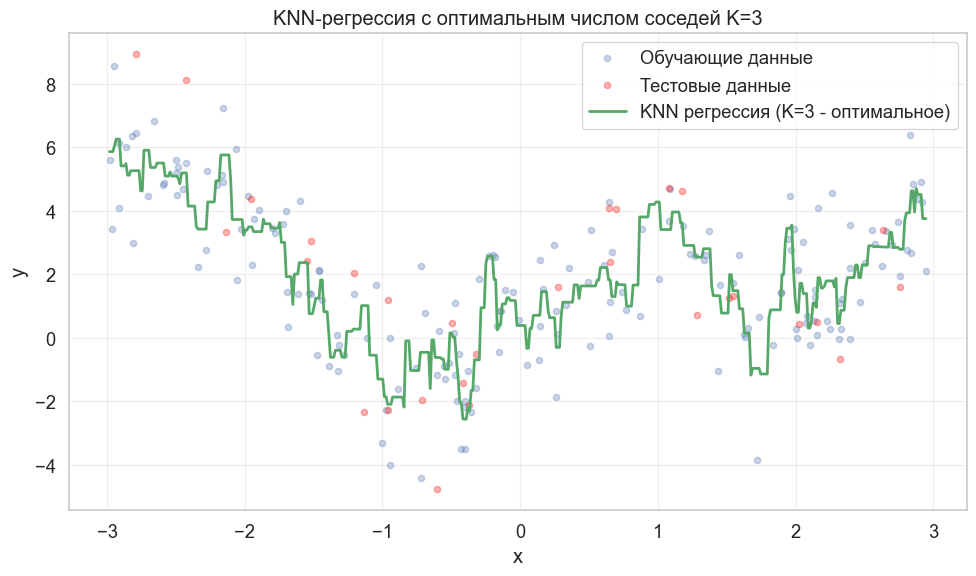

MSE на тестовой выборке при K=3: 3.528974


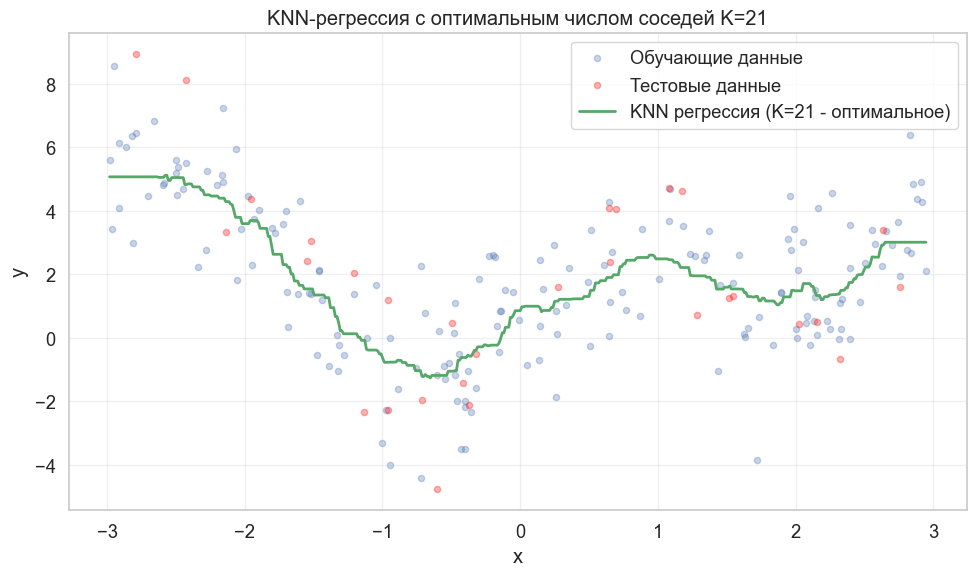

MSE на тестовой выборке при K=21: 3.129410


In [88]:
# Создаем точки для визуализации
X_plot = np.linspace(X_train.min(), X_train.max(), 500).reshape(-1, 1)

# Оптимальный K
knn_optimal = KNeighborsRegressor(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)
y_plot_optimal = knn_optimal.predict(X_plot)

paint_knn_regression(X_train, y_train, X_test, y_test, X_plot, y_plot_optimal, optimal_k)
print(f"MSE на тестовой выборке при K={optimal_k}: {mse_test_knn[k_values.index(optimal_k)]:.6f}")

# Выбираем K меньше оптимального
k_small = max(1, optimal_k // 3)  # Берем примерно треть от оптимального
if k_small % 2 == 0:  # Делаем нечетным
    k_small += 1

knn_small = KNeighborsRegressor(n_neighbors=k_small)
knn_small.fit(X_train, y_train)
y_plot_small = knn_small.predict(X_plot)

# Предсказания для вычисления MSE
y_test_pred_small = knn_small.predict(X_test)
mse_test_small = mean_squared_error(y_test, y_test_pred_small)

paint_knn_regression(X_train, y_train, X_test, y_test, X_plot, y_plot_small, k_small)
print(f"MSE на тестовой выборке при K={k_small}: {mse_test_small:.6f}")

# Выбираем K больше оптимального
k_large = min(51, optimal_k * 3)  # Берем примерно в 3 раза больше
if k_large % 2 == 0:
    k_large += 1

knn_large = KNeighborsRegressor(n_neighbors=k_large)
knn_large.fit(X_train, y_train)
y_plot_large = knn_large.predict(X_plot)

# Предсказания для вычисления MSE
y_test_pred_large = knn_large.predict(X_test)
mse_test_large = mean_squared_error(y_test, y_test_pred_large)

paint_knn_regression(X_train, y_train, X_test, y_test, X_plot, y_plot_large, k_large)
print(f"MSE на тестовой выборке при K={k_large}: {mse_test_large:.6f}")

# Task 6

Сделать выводы о влиянии вида и ширины окна на качество ядерной регрессионной модели.

## Выводы по лабораторной работе: Ядерная регрессия

### 1. Влияние числа интервалов группировки (регрессограмма)

| Интервалов | Характеристика | Результат |
|------------|----------------|-----------|
| 3 | Слишком мало | Высокое смещение, модель не улавливает структуру данных |
| 10 | Оптимально | Лучший баланс смещения и дисперсии, мин. ошибка на валидации |
| 50 | Слишком много | Высокая дисперсия, переобучение (ошибка train << test) |

### 2. Влияние ширины окна

| Ширина окна | Эффект |
|-------------|--------|
| h << optimal | Переобучение: низкое смещение, высокая дисперсия |
| h = optimal | Оптимум: баланс смещения и дисперсии |
| h >> optimal | Недообучение: высокое смещение, низкая дисперсия |

### 3. Сравнение ядерных функций

| Ядро | Особенности |
|------|-------------|
| **Прямоугольное** | Кусочно-постоянное, разрывы на границах |
| **Гауссово** | Бесконечный носитель, наиболее гладкое |
| **Епанечникова** | Оптимальное по эффективности, конечный носитель |
| **Треугольное** | Линейное убывание, промежуточные свойства |

### 4. Оптимальные параметры

| Модель | Параметр | Значение |
|--------|----------|----------|
| Прямоугольное ядро | h | 0.5      |
| Гауссово ядро | h | 0.2      |
| Ядро Епанечникова | h | 0.5      |
| Треугольное ядро | h | 0.6      |
| KNN-регрессия | K | 7        |

### 5. Сравнение с KNN-регрессией

- **KNN**: дискретное сглаживание (равные веса для K соседей)
- **Ядерная регрессия**: непрерывное сглаживание (веса зависят от расстояния)
- Ядерная регрессия дает более гладкие кривые
- KNN проще в реализации и интерпретации

### 6. Ключевые выводы

1. **Универсальный компромисс** смещения и дисперсии проявляется во всех методах
2. **Выбор ширины окна** критичнее выбора типа ядра
3. **Валидационная выборка** необходима для настройки параметров
4. **Непараметрические методы** гибко моделируют нелинейные зависимости
5. **Оптимальные параметры** зависят от структуры конкретных данных